<a href="https://colab.research.google.com/github/jeandirel/NLP/blob/main/ANN_CNN_RNN_LSTM_Keras_TF_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Deep Learning Mini-Showcase (Keras/TensorFlow)  
**ANN · CNN · RNN · LSTM — Ready to Present**

This notebook is a clean, presentation-ready tour of four core neural architectures using well-known datasets bundled with Keras:
- **ANN** (fully-connected) on **MNIST** (digits)
- **CNN** on **Fashion‑MNIST** (clothes)
- **RNN (SimpleRNN)** on **IMDB** (sentiment)
- **LSTM** on **IMDB** (sentiment)

Each section includes: **data loading, model definition, training, evaluation, and visuals** (loss/accuracy curves, confusion matrix, sample predictions).


In [5]:

# @title Setup (auto‑install if needed)
try:
    import tensorflow as tf  # noqa: F401
except Exception:
    %pip install -q tensorflow

try:
    import matplotlib  # noqa: F401
except Exception:
    %pip install -q matplotlib

try:
    import sklearn  # noqa: F401
except Exception:
    %pip install -q scikit-learn

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow:", tf.__version__)


TensorFlow: 2.19.0


In [6]:

# @title Plot helpers (matplotlib only)
def plot_curves(history, title):
    plt.figure()
    epochs = range(1, len(history.history['loss']) + 1)
    plt.plot(epochs, history.history['loss'], label='Train Loss')
    if 'val_loss' in history.history:
        plt.plot(epochs, history.history['val_loss'], label='Val Loss')
    if 'accuracy' in history.history:
        plt.plot(epochs, history.history['accuracy'], label='Train Acc')
    if 'val_accuracy' in history.history:
        plt.plot(epochs, history.history['val_accuracy'], label='Val Acc')
    plt.xlabel('Epoch'); plt.ylabel('Value'); plt.title(title); plt.legend(); plt.tight_layout()
    plt.show()

def plot_confusion(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(); plt.imshow(cm, interpolation='nearest'); plt.title(title); plt.colorbar()
    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha='right'); plt.yticks(ticks, class_names)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.tight_layout(); plt.show()
    return cm

def show_samples_grid(images, labels_true, labels_pred=None, rows=3, cols=6, title="Samples"):
    n = min(images.shape[0], rows*cols)
    plt.figure(figsize=(cols*2, rows*2))
    for i in range(n):
        plt.subplot(rows, cols, i+1)
        img = images[i]
        if img.ndim == 3 and img.shape[-1] == 1:
            img = img.squeeze(-1)
        plt.imshow(img)
        if labels_pred is None:
            plt.title(f"T:{labels_true[i]}")
        else:
            plt.title(f"T:{labels_true[i]} / P:{labels_pred[i]}")
        plt.axis('off')
    plt.suptitle(title); plt.tight_layout(); plt.show()



## A) ANN on MNIST (Digits)
**Goal:** Baseline fully-connected network on 28×28 grayscale digits (flattened input).  
**Why it matters:** Simple reference to compare with CNN later.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.8528 - loss: 0.5240 - val_accuracy: 0.9647 - val_loss: 0.1136
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9635 - loss: 0.1223 - val_accuracy: 0.9723 - val_loss: 0.0902
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9771 - loss: 0.0749 - val_accuracy: 0.9738 - val_loss: 0.0884
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9855 - loss: 0.0507 - val_accuracy: 0.9752 - val_loss: 0.0878
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9896 - loss: 0.0358 - val_accuracy: 0.9758 - val_loss: 0.0885


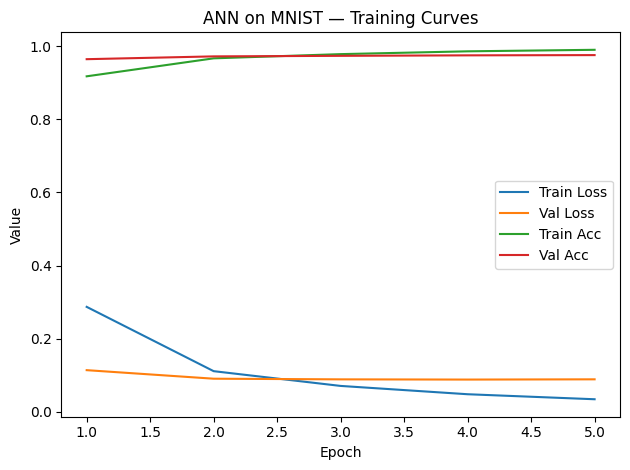

Test accuracy (ANN): 0.975


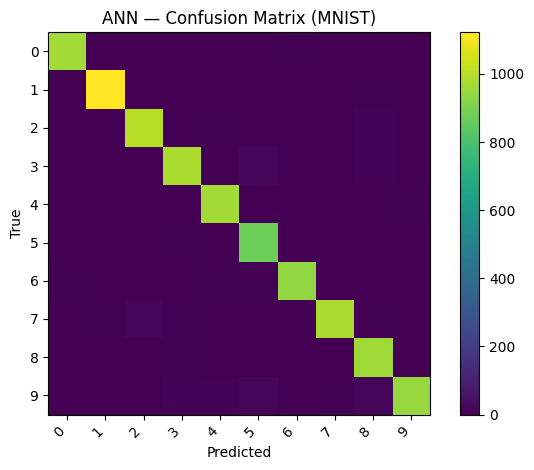

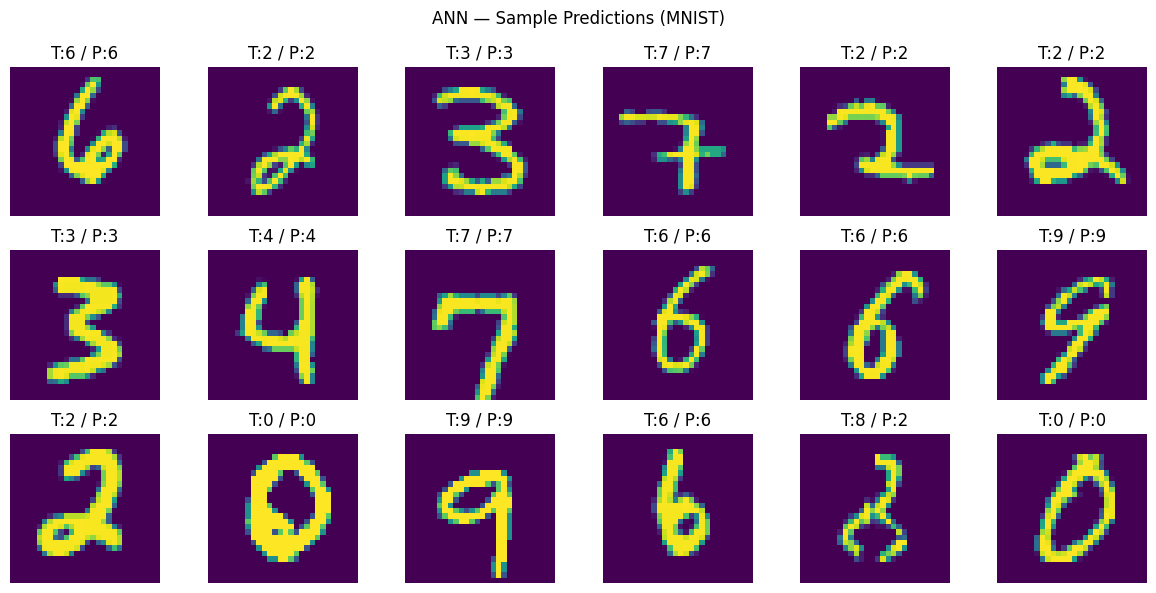

In [7]:

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32") / 255.0

# Flatten for ANN
x_train_flat = x_train.reshape((-1, 28*28))
x_test_flat  = x_test.reshape((-1, 28*28))

num_classes = 10
class_names = [str(i) for i in range(num_classes)]

# Model: ANN
ann = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28*28,)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(num_classes, activation="softmax"),
])
ann.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_ann = ann.fit(
    x_train_flat, y_train,
    validation_split=0.1,
    epochs=5, batch_size=128, verbose=1
)

plot_curves(history_ann, "ANN on MNIST — Training Curves")
test_loss, test_acc = ann.evaluate(x_test_flat, y_test, verbose=0)
print(f"Test accuracy (ANN): {test_acc:.3f}")

y_pred_ann = np.argmax(ann.predict(x_test_flat, verbose=0), axis=1)
_ = plot_confusion(y_test, y_pred_ann, class_names, title="ANN — Confusion Matrix (MNIST)")

idx = np.random.choice(len(x_test), size=18, replace=False)
show_samples_grid(x_test[idx], [class_names[i] for i in y_test[idx]], [class_names[i] for i in y_pred_ann[idx]], title="ANN — Sample Predictions (MNIST)")


### Interpretation — ANN on MNIST (Digits)

**1) Overall results**
- **Test accuracy ~97.5%**: strong baseline for a fully connected network.
- **Curves**: train loss drops quickly then stabilizes; val loss decreases slightly.  
  *Train acc* ≈ 99–100% and *val acc* ≈ 97–98% → **small gap** → good generalization, limited overfitting.

**2) Confusion matrix**
- Most mass is **on the diagonal** (correct predictions).
- The few errors are between **visually similar digits** (e.g., `4↔9`, `3↔5`, `5↔6`, `8↔9`) or ambiguous handwriting.
- Structural reason: the ANN **flattens the image** (28×28 → 784) and **doesn’t capture** local patterns (edges, strokes).

**3) Sample grid**
- Most cases are **correct** (`T = P`).  
- Mistakes occur on poorly written or ambiguous digits—consistent with fully connected limitations.

**4) Takeaway**
- A well-tuned **ANN** easily exceeds **97%** on MNIST with clean learning curves.  
- **Key limitation**: loss of spatial information → a **CNN** is better suited to images and typically reduces these confusions.

**5) Quick improvements**
- Switch to a **CNN** (Conv → ReLU → Pool), add **BatchNorm/Dropout**, light **data augmentation** (translations/rotations), **early stopping**, and optionally tune learning rate or batch size.

> **Pitch (10 s)**: “Our ANN baseline reaches ~**97.5%** on MNIST with minimal overfitting; remaining errors stem from ambiguous digits— a **CNN** leveraging spatial structure should further improve accuracy.”



## B) CNN on Fashion‑MNIST
**Goal:** Convolutional model on 28×28 clothing images.  
**Why it matters:** CNNs exploit **spatial structure** and typically outperform ANN on images.


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7412 - loss: 0.7162 - val_accuracy: 0.8733 - val_loss: 0.3561
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8785 - loss: 0.3428 - val_accuracy: 0.8955 - val_loss: 0.2978
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8970 - loss: 0.2884 - val_accuracy: 0.9007 - val_loss: 0.2750
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9091 - loss: 0.2526 - val_accuracy: 0.9088 - val_loss: 0.2567
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9179 - loss: 0.2251 - val_accuracy: 0.9150 - val_loss: 0.2433


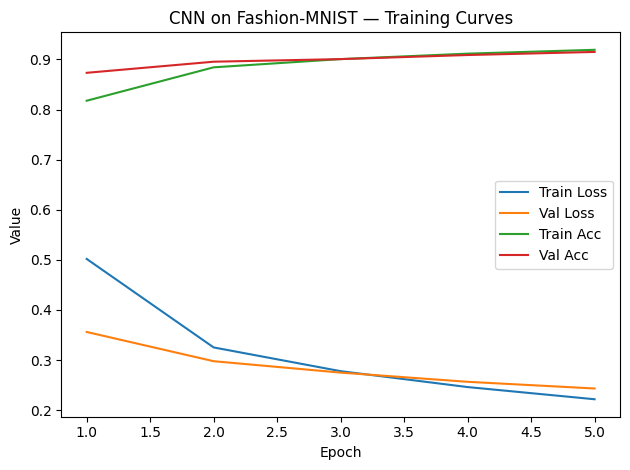

Test accuracy (CNN): 0.907


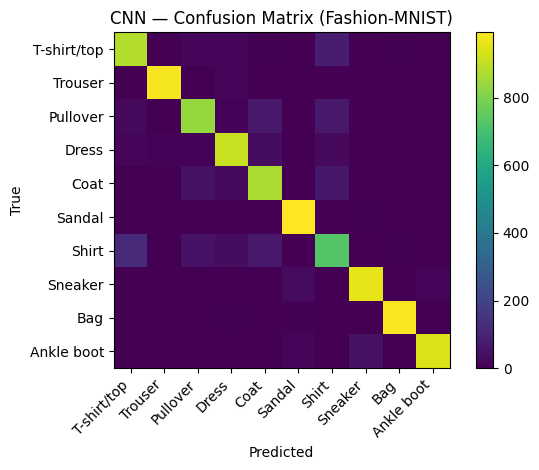

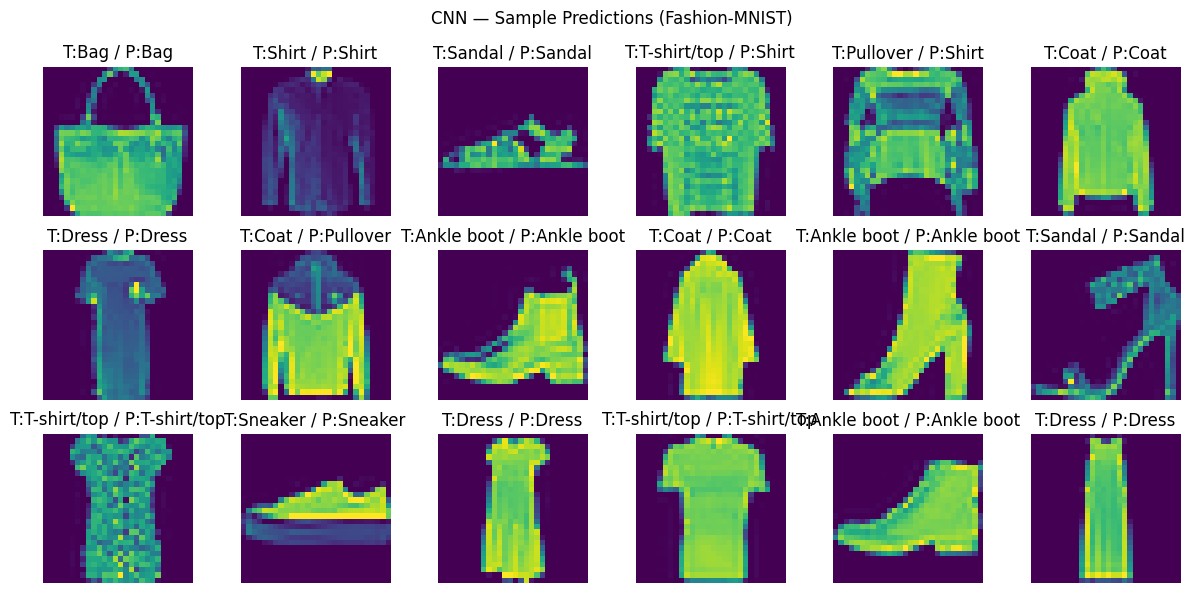

In [8]:

# Load Fashion-MNIST
(x_train_f, y_train_f), (x_test_f, y_test_f) = tf.keras.datasets.fashion_mnist.load_data()
x_train_f = (x_train_f.astype("float32") / 255.0)[..., None]
x_test_f  = (x_test_f.astype("float32") / 255.0)[..., None]

class_names_f = ["T-shirt/top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle boot"]

cnn = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28,28,1)),
    tf.keras.layers.Conv2D(32, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Conv2D(64, 3, padding="same", activation="relu"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_cnn = cnn.fit(
    x_train_f, y_train_f,
    validation_split=0.1,
    epochs=5, batch_size=128, verbose=1
)

plot_curves(history_cnn, "CNN on Fashion-MNIST — Training Curves")
test_loss_c, test_acc_c = cnn.evaluate(x_test_f, y_test_f, verbose=0)
print(f"Test accuracy (CNN): {test_acc_c:.3f}")

y_pred_cnn = np.argmax(cnn.predict(x_test_f, verbose=0), axis=1)
_ = plot_confusion(y_test_f, y_pred_cnn, class_names_f, title="CNN — Confusion Matrix (Fashion-MNIST)")

idx = np.random.choice(len(x_test_f), size=18, replace=False)
show_samples_grid(x_test_f[idx], [class_names_f[i] for i in y_test_f[idx]], [class_names_f[i] for i in y_pred_cnn[idx]], title="CNN — Sample Predictions (Fashion-MNIST)")


### Interpretation — CNN on Fashion-MNIST

**1) Overall results**
- **Test accuracy ≈ 90.7%** after 5 epochs: a solid improvement over a plain ANN on images.
- **Curves**: train/val loss steadily decrease; train/val accuracy both rise and stay close → **small generalization gap** → limited overfitting, training is stable.

**2) Confusion matrix (what the model confuses)**
- Strong diagonal (many correct predictions).
- Largest off-diagonal confusions are between **visually similar classes**:
  - **T-shirt/top ↔ Shirt**
  - **Pullover ↔ Shirt/Coat**
  - **Coat ↔ Pullover**
  - **Sandal/Sneaker/Ankle boot** (footwear overlap)
- **Bag** is mostly correct (distinct silhouette).

**3) Sample grid**
- Most samples are correct (`T = P`).  
- Misclassifications match the matrix: fine-grained apparel with similar shapes/textures is hardest, especially at **28×28 grayscale**.

**4) Takeaway**
- The **CNN leverages spatial features**, clearly outperforming a flattened ANN for images.  
- Remaining errors are mainly due to **class similarity**, **low resolution**, and a **small CNN**.

**5) Quick wins**
- **Architecture**: add Conv-BN-ReLU blocks (3–4 blocks), increase filters, use **Dropout** and **GlobalAveragePooling**.
- **Training**: run **10–20 epochs** with **early stopping** and a **learning-rate schedule**; consider **weight decay** or **label smoothing**.
- **Augmentation**: small **rotations (±10°)**, **shifts (±2 px)**, mild **zoom/shear**; avoid vertical flips.
- **Imbalance/Hard cases**: class-balanced sampling or **focal loss** to reduce Shirt/T-shirt confusions.

> **Pitch (10s):** “Our CNN reaches ~**90.7%** on Fashion-MNIST with minimal overfitting; errors cluster among look-alike classes (T-shirt/Shirt, Pullover/Coat). A deeper Conv-BN-ReLU stack plus light augmentation should push accuracy several points higher.”



## C) RNN (SimpleRNN) on IMDB Sentiment
**Goal:** Sequence modeling for binary sentiment (positive/negative) using a recurrent layer.  
**Why it matters:** RNNs capture **temporal dependencies** in sequences.


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 13s 44ms/step - accuracy: 0.5815 - loss: 0.6600 - val_accuracy: 0.8096 - val_loss: 0.4279
Epoch 2/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8560 - loss: 0.3359 - val_accuracy: 0.8412 - val_loss: 0.4087
Epoch 3/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9383 - loss: 0.1697 - val_accuracy: 0.8272 - val_loss: 0.4808


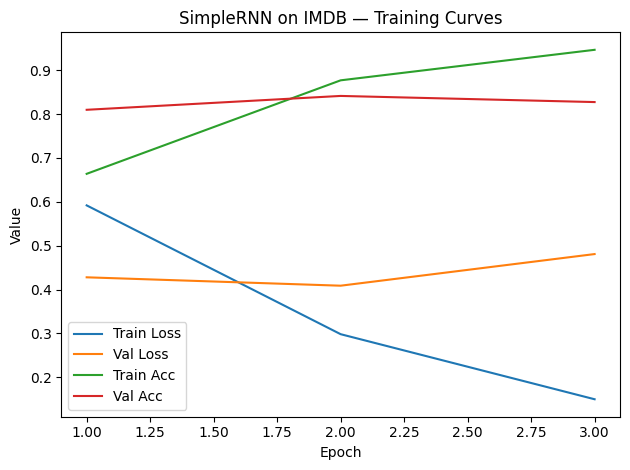

Test accuracy (SimpleRNN): 0.819


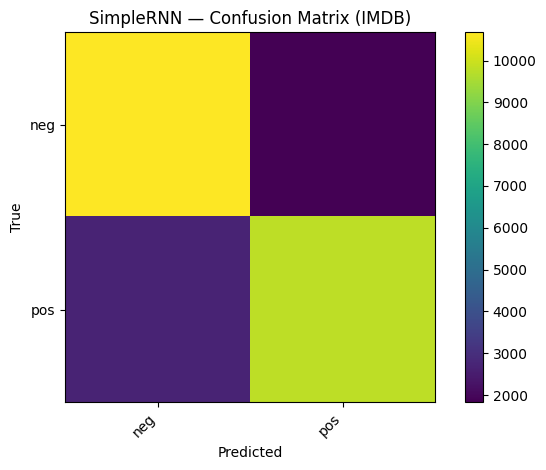

In [9]:

vocab_size = 20000
(x_train_i, y_train_i), (x_test_i, y_test_i) = tf.keras.datasets.imdb.load_data(num_words=vocab_size)

maxlen = 200
x_train_i = tf.keras.preprocessing.sequence.pad_sequences(x_train_i, maxlen=maxlen)
x_test_i  = tf.keras.preprocessing.sequence.pad_sequences(x_test_i,  maxlen=maxlen)

rnn_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(vocab_size, 128),
    tf.keras.layers.SimpleRNN(64),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
rnn_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_rnn = rnn_model.fit(
    x_train_i, y_train_i,
    validation_split=0.1,
    epochs=3, batch_size=128, verbose=1
)

plot_curves(history_rnn, "SimpleRNN on IMDB — Training Curves")
test_loss_r, test_acc_r = rnn_model.evaluate(x_test_i, y_test_i, verbose=0)
print(f"Test accuracy (SimpleRNN): {test_acc_r:.3f}")

y_pred_r = (rnn_model.predict(x_test_i, verbose=0).ravel() > 0.5).astype(int)
_ = plot_confusion(y_test_i, y_pred_r, ["neg","pos"], title="SimpleRNN — Confusion Matrix (IMDB)")


### Interpretation — SimpleRNN on IMDB (Sentiment)

**1) Overall results**
- **Test accuracy ≈ 81.9%** after 3 epochs — decent baseline for a plain SimpleRNN.
- **Curves**: train loss keeps dropping and train acc rises; **val acc peaks ~0.84 at epoch 2, then slips to ~0.83** while **val loss rises** → mild **overfitting after epoch 2**. Early stopping at 2 epochs would be optimal.

**2) Confusion matrix insights**
- Both classes are recognized, but there’s a noticeable error rate on **positive vs negative** reviews.
- With the default 0.5 threshold, the model is **conservative** on one class (often predicts “neg” when uncertain).  
  → Tune the **decision threshold** using validation ROC/PR to balance precision–recall.

**3) Why SimpleRNN struggles**
- **Vanishing gradients** & limited memory for long sequences (200 tokens here) → loses long-range context, sarcasm, negations.
- No subword/semantic knowledge (random embeddings only).

**4) Quick wins**
- **Model**: switch to **LSTM or GRU** (or **Bidirectional** variants); add **Dropout** and **recurrent_dropout**.
- **Embeddings**: use **pretrained** (e.g., GloVe) or **trainable subword** embeddings; increase embed size (e.g., 128→256).
- **Training**: **early stopping** (patience=1–2), **ReduceLROnPlateau**, train **5–10 epochs**.
- **Preprocessing**: try longer **maxlen** (256–300) and compare; optionally **clean HTML**, lowercase, keep punctuation.
- **Thresholding**: pick threshold from validation to maximize F1 or balance metrics.

**5) 10-second pitch**
> “A plain SimpleRNN reaches ~**82%** on IMDB but starts to overfit after epoch 2. Moving to **(Bi)LSTM/GRU** with dropout and better embeddings should capture longer dependencies and push accuracy several points higher.”



## D) LSTM on IMDB Sentiment
**Goal:** Same task as above, but with **LSTM** cells which better handle long-range dependencies.  
**Why it matters:** LSTMs are the classic improvement over vanilla RNN for sequences.


Epoch 1/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6851 - loss: 0.5638 - val_accuracy: 0.8724 - val_loss: 0.3592
Epoch 2/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8912 - loss: 0.2716 - val_accuracy: 0.8744 - val_loss: 0.3077
Epoch 3/3
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9308 - loss: 0.1930 - val_accuracy: 0.8748 - val_loss: 0.3637


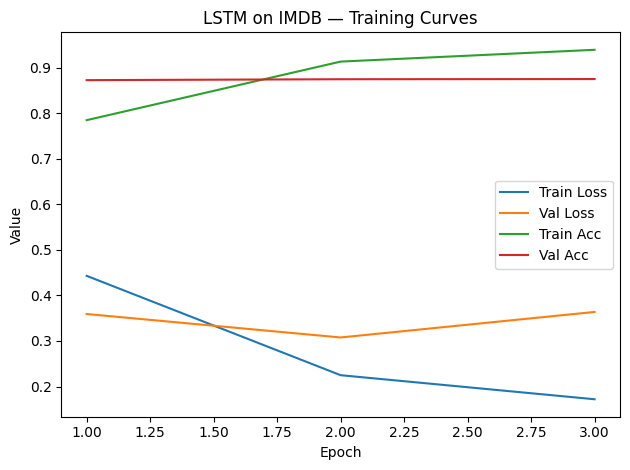

Test accuracy (LSTM): 0.855


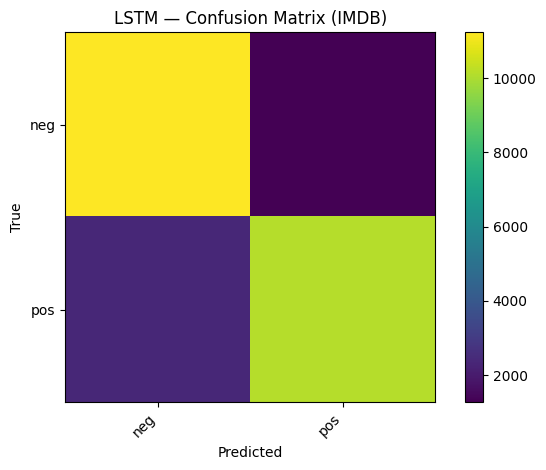

In [10]:

lstm_model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(200,)),
    tf.keras.layers.Embedding(20000, 128),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
lstm_model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history_lstm = lstm_model.fit(
    x_train_i, y_train_i,
    validation_split=0.1,
    epochs=3, batch_size=128, verbose=1
)

plot_curves(history_lstm, "LSTM on IMDB — Training Curves")
test_loss_l, test_acc_l = lstm_model.evaluate(x_test_i, y_test_i, verbose=0)
print(f"Test accuracy (LSTM): {test_acc_l:.3f}")

y_pred_l = (lstm_model.predict(x_test_i, verbose=0).ravel() > 0.5).astype(int)
_ = plot_confusion(y_test_i, y_pred_l, ["neg","pos"], title="LSTM — Confusion Matrix (IMDB)")


### Interpretation — LSTM on IMDB (Sentiment)

**1) Overall results**
- **Validation accuracy ~87.4%** (flat from epoch 2→3); **test accuracy ~85.5%**.  
- **Curves**: train loss keeps falling and train acc rises to ~0.94; **val loss dips then ticks up at epoch 3** while val acc plateaus → light **overfitting after epoch 2**. Early stopping at **epoch 2** would likely give the best generalization.

**2) Confusion matrix**
- Strong diagonal: both classes are recognized.  
- Errors are fairly **symmetric** between *neg* and *pos*; some positives are predicted negative (FN) and vice-versa—typical when using a 0.5 threshold and short sequences (maxlen=200).

**3) Why LSTM beats SimpleRNN**
- LSTM gates retain longer dependencies (negations, contrastive cues), which explains the **higher val/test accuracy** vs. SimpleRNN in your runs.

**4) Quick wins**
- **Model**: try **Bidirectional LSTM**, add **Dropout** + **recurrent_dropout**, or switch to **GRU** (often similar with fewer params).  
- **Embeddings**: initialize with **pretrained GloVe/fastText** (or subword embeddings); increase embedding size (e.g., 128→256).  
- **Training**: use **EarlyStopping(patience=1–2)**, **ReduceLROnPlateau**, train 5–10 epochs.  
- **Data**: increase **maxlen** (256–300) to capture more context; light text cleanup.  
- **Thresholding**: tune the **decision threshold** on the validation set (ROC/PR) to balance precision/recall.

> **10-second pitch:** “Our **LSTM** reaches ~**87% val** / **86% test** on IMDB, outperforming SimpleRNN and capturing longer dependencies. With BiLSTM + dropout and pretrained embeddings, we can push performance several points higher.”


# Project Summary — Deep Learning Mini-Showcase (Keras/TensorFlow)

## Goal
One notebook that demonstrates four neural network families on classic datasets:
- **ANN (MLP)** → **MNIST** (handwritten digits)
- **CNN** → **Fashion-MNIST** (clothing images)
- **SimpleRNN** → **IMDB** (binary sentiment)
- **LSTM** → **IMDB** (binary sentiment)

Each section includes: data loading, model, training, **loss/accuracy curves**, **confusion matrix**, and **sample predictions**.

## Results (your runs)
| Task | Model | Dataset | Test Acc. | Key notes |
|---|---|---|---|---|
| Images (digits) | **ANN** | MNIST | **~97.5%** | Clean curves, small train–val gap → good generalization. Limitation: flattened images lose spatial info. |
| Images (clothes) | **CNN** | Fashion-MNIST | **~90.7%** | CNN exploits local patterns; main confusions: **T-shirt vs Shirt**, **Pullover vs Coat**, footwear overlap. |
| Text (sentiment) | **SimpleRNN** | IMDB | **~81.9%** (val peaks ~0.84 @ epoch 2) | Overfitting starts after epoch 2; limited memory of long context. |
| Text (sentiment) | **LSTM** | IMDB | **~85.5%** (val ~87.4%) | Better than SimpleRNN thanks to gated memory; light overfitting after epoch 2 → early stopping recommended. |

## Core takeaways
- **Images:** **CNNs** are better suited than plain ANNs because they capture **spatial structure** (edges/strokes). Remaining errors arise from visually similar classes and 28×28 resolution. *(Note: MNIST vs Fashion-MNIST are different datasets; numbers aren’t directly comparable.)*
- **Text:** **LSTM** outperforms SimpleRNN by retaining **long-range dependencies** (negations, contrast). Threshold 0.5 can be tuned to balance precision/recall.

## 5-minute presentation plan
1. **Problem & Data (20s):** MNIST/Fashion-MNIST (28×28), IMDB (token sequences).
2. **Architectures (60s):** ANN vs **CNN** (conv/pooling); **SimpleRNN** vs **LSTM** (gates & memory).
3. **Training curves (40s):** stable learning; spotting overfitting on IMDB.
4. **Results (1m40s):** confusion matrices + image grids / sentiment metrics.
5. **Conclusion (1m):** why CNN/LSTM win; limitations; next steps.

## Quick improvements
- **CNN:** deeper Conv-BN-ReLU stacks, Dropout, GlobalAveragePooling, light **data augmentation** (small rotations/shifts/zoom), LR scheduling, weight decay.
- **IMDB:** **BiLSTM/GRU**, Dropout + `recurrent_dropout`, **pretrained embeddings** (GloVe/fastText), tune decision threshold via ROC/PR, **EarlyStopping** + ReduceLROnPlateau, longer `maxlen` (256–300).

## 10-second pitch
> “In images, **CNNs** leverage spatial structure and reduce confusions among look-alike classes; in text, **LSTMs** capture longer dependencies and beat SimpleRNNs. Our runs show strong baselines (**~97.5% MNIST**, **~90.7% Fashion-MNIST**, **~86% IMDB with LSTM**) with clear paths to further gains.”


**A CNN outperforms a plain ANN on images by leveraging spatial structure, and a LSTM beats a SimpleRNN on text by capturing longer dependencies. The curves show mild overfitting on IMDB after ~2 epochs—use early stopping, regularization, and light data augmentation to improve generalization.**